# IT Ticket Classification using SBERT (Sentence-BERT)

## What is SBERT?

**SBERT (Sentence-BERT)** is a modification of the BERT model that produces **semantically meaningful sentence embeddings**.

Unlike TF-IDF which treats text as a bag of individual words:
- SBERT **understands word order** — "server crashed the app" ≠ "app crashed the server"
- SBERT **understands synonyms** — "VPN not working" and "virtual private network is down" produce similar vectors
- SBERT **understands context** — the meaning of each word depends on surrounding words
- SBERT produces **dense, fixed-size vectors** (e.g., 384 dimensions) instead of sparse 5000-dimension TF-IDF vectors

## How it works

```
Ticket Text → SBERT Model → Dense Vector (384 floats) → Classifier → Predicted Queue
```

The SBERT model (`all-MiniLM-L6-v2`) was pre-trained on millions of text pairs to learn that similar meanings → similar vectors.

We use it as a **feature extractor** — convert all ticket text to vectors, then train a simple classifier on those vectors.

---

**Dataset:** `data/support_tickets.csv` (5000 IT support tickets)  
**Target:** `assigned_queue` (Network Team, Database Team, Application Team, Infrastructure Team, Security Team)  
**Model:** `all-MiniLM-L6-v2` (fast, 384-dim embeddings, ~80 MB)

## Step 1: Load the Data

In [1]:
import pandas as pd

df = pd.read_csv("data/support_tickets.csv")
df.head()

,ticket_id,summary,description,priority,assigned_queue
0,INC11502,Help needed - Database replication lag is incr...,Stored procedure sp_calculate_commission is re...,Medium,Database Team
1,INC12587,URGENT: Error 500 on checkout page,Checkout page returning HTTP 500 when users ap...,High,Application Team
2,INC12654,Batch job stuck in running state - please help,Nightly batch job for invoice generation has b...,High,Application Team
3,INC11056,Issue: Need database user created for new appl...,Data migration from Oracle to PostgreSQL faili...,High,Database Team
4,INC10706,Request: VPN connection dropping frequently - ...,Getting disconnected from VPN every 10 minutes...,Critical,Network Team


In [ ]:
df.shape

In [2]:
print(df.isna().sum())
print(df.assigned_queue.value_counts())

ticket_id         0
summary           0
description       0
priority          0
assigned_queue    0
dtype: int64
assigned_queue
Database Team          1000
Application Team       1000
Network Team           1000
Infrastructure Team    1000
Security Team          1000
Name: count, dtype: int64


## Step 2: Combine Text Fields

Just like in TF-IDF approach, we combine `summary` and `description` into a single text.
SBERT will read this full text and produce one vector that captures the overall meaning.

In [3]:
df["text"] = df["summary"] + " " + df["description"]
df[["text", "assigned_queue"]].head()

,text,assigned_queue
0,Help needed - Database replication lag is incr...,Database Team
1,URGENT: Error 500 on checkout page Checkout pa...,Application Team
2,Batch job stuck in running state - please help...,Application Team
3,Issue: Need database user created for new appl...,Database Team
4,Request: VPN connection dropping frequently - ...,Network Team


In [4]:
print(f"Sample ticket text:\n{df['text'].iloc[0]}")
print(f"\nText length stats:")
print(df["text"].str.len().describe())

Sample ticket text:
Help needed - Database replication lag is increasing Stored procedure sp_calculate_commission is returning negative values for some sales reps. Logic seems incorrect after the last update.

Text length stats:
count    5000.000000
mean      177.414000
std        19.460924
min       122.000000
25%       165.000000
50%       178.000000
75%       190.000000
max       241.000000
Name: text, dtype: float64


## Step 3: Generate SBERT Embeddings

This is the key step that replaces TF-IDF.

**TF-IDF:** `text → sparse vector of word counts (5000 dims, mostly zeros)`  
**SBERT:** `text → dense vector of meaning (384 dims, all meaningful floats)`

The model `all-MiniLM-L6-v2` is:
- Fast (6 transformer layers vs 12 in full BERT)
- Small (~80 MB download)
- Produces 384-dimensional embeddings
- Good quality for general-purpose English text

First run will download the model (~80 MB). Subsequent runs use the cached version.

In [5]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded. Embedding dimension: {sbert_model.get_sentence_embedding_dimension()}")

c:\Dev\gcp\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2579.31it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Embedding dimension: 384


C:\Users\deepeshv\AppData\Local\Temp\ipykernel_42484\316549304.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded. Embedding dimension: {sbert_model.get_sentence_embedding_dimension()}")


In [6]:
%%time

embeddings = sbert_model.encode(df["text"].tolist(), show_progress_bar=True)
print(f"Embeddings shape: {embeddings.shape}")

Batches: 100%|██████████| 157/157 [01:13<00:00,  2.14it/s]

Embeddings shape: (5000, 384)
CPU times: total: 2min 28s
Wall time: 1min 13s


### Understand What an Embedding Looks Like

Each ticket is now a vector of 384 floating-point numbers.
These numbers don't map to specific words — they represent **abstract meaning dimensions** learned during pre-training.

In [7]:
print(f"Ticket: {df['text'].iloc[0][:80]}...")
print(f"\nEmbedding (first 20 values): {embeddings[0][:20]}")
print(f"\nMin: {embeddings[0].min():.4f}, Max: {embeddings[0].max():.4f}, Mean: {embeddings[0].mean():.4f}")

Ticket: Help needed - Database replication lag is increasing Stored procedure sp_calcula...

Embedding (first 20 values): [-0.00225235 -0.05056475 -0.07246505  0.02429563 -0.13377927 -0.05067977
 -0.05620981 -0.04206948  0.01740862  0.06134108  0.10522786  0.02748511
  0.03493451 -0.02044277  0.00665762  0.00141569  0.06150109 -0.04089624
 -0.01295403 -0.00500405]

Min: -0.1338, Max: 0.1373, Mean: 0.0010


### Semantic Similarity Demo

Let's verify SBERT understands meaning. Two tickets about the same topic should have **high cosine similarity** (close to 1.0), even if they use different words.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

sentences = [
    "VPN connection is not working from home",
    "Cannot establish virtual private network tunnel remotely",  # same meaning, different words
    "Database backup job failed overnight",                       # completely different topic
]

demo_embeddings = sbert_model.encode(sentences)
sim_matrix = cosine_similarity(demo_embeddings)

print("Cosine Similarity Matrix:")
print(f"  VPN sentence 1 vs VPN sentence 2 (same topic):       {sim_matrix[0][1]:.4f}")
print(f"  VPN sentence 1 vs Database sentence (different topic): {sim_matrix[0][2]:.4f}")

Cosine Similarity Matrix:
  VPN sentence 1 vs VPN sentence 2 (same topic):       0.4983
  VPN sentence 1 vs Database sentence (different topic): 0.1680


## Step 4: Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

y = df["assigned_queue"]
x_train, x_test, y_train, y_test = train_test_split(embeddings, y, test_size=0.2, random_state=42)

print(f"Training set: {x_train.shape}")
print(f"Test set:     {x_test.shape}")



# x_train[:5]

Training set: (4000, 384)
Test set:     (1000, 384)


## Step 5: Train Classifiers on SBERT Embeddings

Now we use the dense 384-dim vectors as features for our classifiers.
Since embeddings are dense and meaningful, even simple classifiers work well.

---
### Model 1: Logistic Regression

Often the best first choice for SBERT embeddings — fast, interpretable, and works great with dense features.

In [10]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
lr_model.score(x_test, y_test)

1.0

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_lr = lr_model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[192   0   0   0   0]
 [  0 214   0   0   0]
 [  0   0 208   0   0]
 [  0   0   0 178   0]
 [  0   0   0   0 208]]

Classification Report:
                     precision    recall  f1-score   support

   Application Team       1.00      1.00      1.00       192
      Database Team       1.00      1.00      1.00       214
Infrastructure Team       1.00      1.00      1.00       208
       Network Team       1.00      1.00      1.00       178
      Security Team       1.00      1.00      1.00       208

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



---
### Model 2: Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
rf_model.score(x_test, y_test)

1.0

In [15]:
y_pred_rf = rf_model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[192   0   0   0   0]
 [  0 214   0   0   0]
 [  0   0 208   0   0]
 [  0   0   0 178   0]
 [  0   0   0   0 208]]

Classification Report:
                     precision    recall  f1-score   support

   Application Team       1.00      1.00      1.00       192
      Database Team       1.00      1.00      1.00       214
Infrastructure Team       1.00      1.00      1.00       208
       Network Team       1.00      1.00      1.00       178
      Security Team       1.00      1.00      1.00       208

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



---
### Model 3: Naive Bayes (GaussianNB)

We use GaussianNB here (not MultinomialNB) because SBERT embeddings contain negative values.
MultinomialNB requires non-negative inputs (like TF-IDF counts).

In [16]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [17]:
nb_model.score(x_test, y_test)

1.0

In [18]:
y_pred_nb = nb_model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Confusion Matrix:
[[192   0   0   0   0]
 [  0 214   0   0   0]
 [  0   0 208   0   0]
 [  0   0   0 178   0]
 [  0   0   0   0 208]]

Classification Report:
                     precision    recall  f1-score   support

   Application Team       1.00      1.00      1.00       192
      Database Team       1.00      1.00      1.00       214
Infrastructure Team       1.00      1.00      1.00       208
       Network Team       1.00      1.00      1.00       178
      Security Team       1.00      1.00      1.00       208

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



---
## Step 6: Compare All Models

Logistic Regression       → 1.0000
Random Forest             → 1.0000
Gaussian Naive Bayes      → 1.0000


(0.0, 1.0)

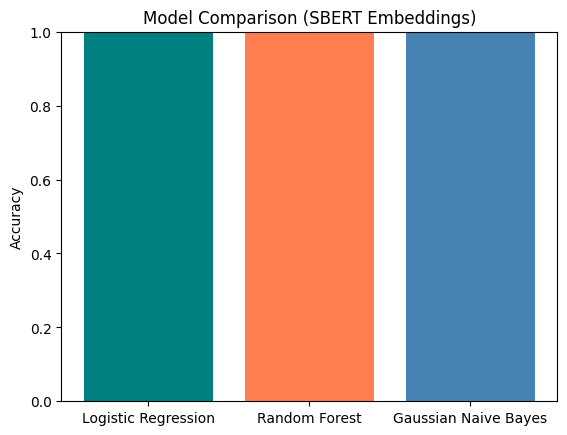

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

models = {
    "Logistic Regression": lr_model.score(x_test, y_test),
    "Random Forest": rf_model.score(x_test, y_test),
    "Gaussian Naive Bayes": nb_model.score(x_test, y_test),
}

for name, score in models.items():
    print(f"{name:25s} → {score:.4f}")

plt.bar(models.keys(), models.values(), color=["teal", "coral", "steelblue"])
plt.ylabel("Accuracy")
plt.title("Model Comparison (SBERT Embeddings)")
plt.ylim(0, 1.0)

---
## Step 7: Predict Queue for New Tickets

This is how it would work in production:
1. New ticket comes in with summary and description
2. SBERT converts text to a 384-dim vector
3. Classifier predicts the queue
4. If confidence is high → auto-route. If low → send to Service Desk.

In [23]:
def predict_queue(ticket_text, model=lr_model):
    """Predict the queue for a new ticket and show confidence."""
    embedding = sbert_model.encode([ticket_text])
    prediction = model.predict(embedding)[0]
    probabilities = model.predict_proba(embedding)[0]
    confidence = max(probabilities)
    
    print(f"Ticket:     {ticket_text}")
    print(f"Queue:      {prediction}")
    print(f"Confidence: {confidence:.2%}")
    print(f"\nAll probabilities:")
    for queue, prob in sorted(zip(model.classes_, probabilities), key=lambda x: -x[1]):
        bar = "█" * int(prob * 40)
        print(f"  {queue:25s} {prob:.2%} {bar}")
    print()

In [24]:
predict_queue("Users cannot connect to VPN from home office. Getting SSL handshake error on Cisco client.")

Ticket:     Users cannot connect to VPN from home office. Getting SSL handshake error on Cisco client.
Queue:      Network Team
Confidence: 93.73%

All probabilities:
  Network Team              93.73% █████████████████████████████████████
  Security Team             4.28% █
  Application Team          0.96% 
  Database Team             0.66% 
  Infrastructure Team       0.36% 



In [25]:
predict_queue("Production Oracle database running out of tablespace. Need DBA to add datafile urgently.")

Ticket:     Production Oracle database running out of tablespace. Need DBA to add datafile urgently.
Queue:      Database Team
Confidence: 98.53%

All probabilities:
  Database Team             98.53% ███████████████████████████████████████
  Infrastructure Team       0.59% 
  Security Team             0.54% 
  Application Team          0.27% 
  Network Team              0.07% 



In [36]:
predict_queue("cloud user to be created")

Ticket:     cloud user to be created
Queue:      Infrastructure Team
Confidence: 57.56%

All probabilities:
  Infrastructure Team       57.56% ███████████████████████
  Security Team             38.27% ███████████████
  Database Team             1.66% 
  Application Team          1.39% 
  Network Team              1.11% 



In [37]:
predict_queue("Kubernetes pods crashing with OOMKilled error. Need to increase memory limits on deployment.")

Ticket:     Kubernetes pods crashing with OOMKilled error. Need to increase memory limits on deployment.
Queue:      Infrastructure Team
Confidence: 91.57%

All probabilities:
  Infrastructure Team       91.57% ████████████████████████████████████
  Application Team          6.51% ██
  Database Team             1.39% 
  Network Team              0.33% 
  Security Team             0.20% 



In [38]:
predict_queue("Checkout page returning HTTP 500 after latest deployment. Users unable to complete orders.")

Ticket:     Checkout page returning HTTP 500 after latest deployment. Users unable to complete orders.
Queue:      Application Team
Confidence: 93.40%

All probabilities:
  Application Team          93.40% █████████████████████████████████████
  Infrastructure Team       3.15% █
  Network Team              2.13% 
  Security Team             0.96% 
  Database Team             0.36% 



---
## Step 8: SBERT vs TF-IDF Comparison

Let's compare SBERT embeddings against TF-IDF on the same data and same classifier to see the difference.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
x_tfidf = tfidf.fit_transform(df["text"])

x_train_tf, x_test_tf, y_train_tf, y_test_tf = train_test_split(x_tfidf, y, test_size=0.2, random_state=42)

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(x_train_tf, y_train_tf)

print(f"TF-IDF + Logistic Regression:  {lr_tfidf.score(x_test_tf, y_test_tf):.4f}")
print(f"SBERT  + Logistic Regression:  {lr_model.score(x_test, y_test):.4f}")
print(f"\nFeature dimensions:")
print(f"  TF-IDF: {x_tfidf.shape[1]} (sparse)")
print(f"  SBERT:  {embeddings.shape[1]} (dense)")

TF-IDF + Logistic Regression:  1.0000
SBERT  + Logistic Regression:  1.0000

Feature dimensions:
  TF-IDF: 697 (sparse)
  SBERT:  384 (dense)


---
## Summary

| Aspect | TF-IDF | SBERT |
|--------|--------|-------|
| **How it works** | Counts word frequencies | Understands sentence meaning |
| **Vector size** | 5000 (sparse, mostly zeros) | 384 (dense, all meaningful) |
| **Synonyms** | Treated as different words | Understood as similar |
| **Word order** | Ignored | Understood |
| **Speed** | Very fast (no model needed) | Slower (runs neural network) |
| **Setup** | Just scikit-learn | Needs sentence-transformers + PyTorch |
| **Best for** | Learning, prototyping | Production systems |